In [8]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
) 
vv = VQAResults()   
human_vqa = vv.human 

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 55.83173855421686
after  55.98475060240963
[]
before 56.54445633752563
after  56.68585294518072


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:405: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:405: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


In [9]:
mm = MMStarResults()

/home/work/yuna/HPA/evaluation/analysis/analyzer.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


14 6
[]


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['category'].map(mmstar_cat_map)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['question_id'] = df['question_id'].astype('Int64')


In [5]:
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]   

processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

In [5]:
vv.get_examples_quadrants() 

Shared Wrong 159842001 
Note: No images are provided. For each question, imagine an appropriate image exists and answer based on the most common or universal scenario.
Question: What color is her headband? Answer the question using a single word or phrase. 
Answer: pink


KeyError: "['MG'] not in index"

In [38]:
mms.groupby(['cc_quadrant'])['MG'].mean() 

cc_quadrant
Human-Only        60.943168
Model-Only       -24.905050
Shared Correct   -19.414484
Shared Wrong      47.491255
Name: MG, dtype: float64

In [10]:
vvs= vv.quadrants
vvs[vvs['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-vqa.tex', float_format="%.1f") 

mms = mm.get_quadrants()
mms[mms['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-mmstar.tex', float_format="%.1f")   

vvs['dataset'] = 'VQAv2' 
mms['dataset'] = 'MMStar'

qmg = pd.concat([vvs, mms]).reset_index()

In [28]:
qmg.groupby(['cc_quadrant', 'dataset'])['MG'].mean()

cc_quadrant     dataset
Human-Only      MMStar     60.943168
                VQAv2      82.215179
Model-Only      MMStar    -24.905050
                VQAv2      -8.105977
Shared Correct  MMStar    -19.414484
                VQAv2      -2.957979
Shared Wrong    MMStar     47.491255
                VQAv2      69.395379
Name: MG, dtype: float64

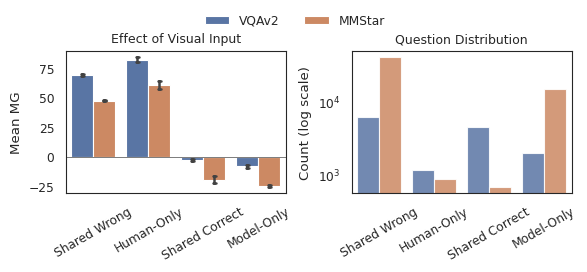

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(
    1, 2,
    figsize=(5.8, 2.4),
    sharex=True
)

palette = sns.color_palette("deep", n_colors=2)

# ---- Panel (a): Mean MG ----
sns.barplot(
    data=qmg,
    x="cc_quadrant",
    y="MG",
    hue="dataset",
    ax=axes[0],
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.12
)
axes[0].set_title("Effect of Visual Input", fontsize=9)
axes[0].set_ylabel("Mean MG")
axes[0].set_xlabel("")
axes[0].axhline(0, color="black", linewidth=0.6, alpha=0.6)

# ---- Panel (b): Counts ----
sns.countplot(
    data=qmg,
    x="cc_quadrant",
    hue="dataset",
    ax=axes[1],
    palette=palette,
    alpha=0.85
)
axes[1].set_yscale("log")
axes[1].set_title("Question Distribution", fontsize=9)
axes[1].set_ylabel("Count (log scale)")
axes[1].set_xlabel("")

# ---- Remove individual legends ----
for ax in axes:
    ax.legend_.remove()
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.tick_params(axis="x", rotation=30)

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    # title="Dataset",
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.1)
)

plt.tight_layout(pad=0.4)
plt.savefig("quadrant_mg_unified.pdf", bbox_inches="tight")
plt.show()

<Axes: xlabel='cc_quadrant', ylabel='MG'>

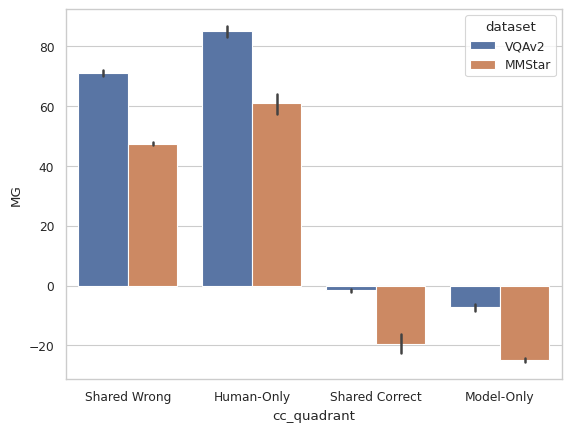

In [37]:

# qmg= qmg[qmg['finetuned'] == "Pretrained"]  
qmg.pivot_table(
    index=['cc_quadrant'] , 
    values=['MG'] , 
    columns=['dataset'] , 
    aggfunc = ['count', 'mean'] ).to_latex('./tables/quadrant-stats.tex', float_format="%.1f") 
sns.barplot(qmg, x='cc_quadrant', y='MG', hue='dataset') 